# Appendix A: Fredholm Theory

    **Source orientation:** McDuff-Salamon, *J-holomorphic Curves and Symplectic Topology*, Appendix A, printed pp. 531-548; PDF pp. 546-563. Sections: A.1-A.5.

    ## Chapter Goal

    Fredholm operators, determinant line bundles, implicit function theorem, finite-dimensional reduction, and Sard-Smale theorem.

    The guiding question is:

    > Which finite-dimensional features of a linear map survive inside infinite-dimensional analysis?

    ## Computational Translation Guide

    | Chapter language | Computational object | Inspection target / check |
| --- | --- | --- |
| Fredholm operator | matrix with stable finite defect | dim ker - dim coker |
| determinant line | top exterior powers of kernel and cokernel | orientation sign |
| implicit function theorem | surjective derivative | local zero-set dimension |
| finite-dimensional reduction | project to cokernel obstruction | obstruction rank |
| Sard-Smale | generic regular values | residual set check |


## Standalone Reading Guide

    The appendix supplies the functional-analytic language used throughout the course. A Fredholm operator behaves like a finite matrix in the two ways moduli theory needs: its kernel and cokernel are finite-dimensional, and its image is closed. The index packages the difference between infinitesimal freedoms and infinitesimal obstructions.

In curve theory, the linearized Cauchy-Riemann operator is Fredholm after choosing Sobolev completions. Surjectivity means no cokernel obstruction, so the moduli space is locally modeled on the kernel. Determinant lines then supply orientation data for signed counts. Sard-Smale is the infinite-dimensional transversality theorem that justifies generic choices.

The finite matrix below is not a Fredholm theorem, but it is the right visual grammar. Singular values near zero identify kernel directions; missing rank in the target identifies cokernel directions. The index is stable under small perturbations that do not create or destroy small singular values across the chosen threshold.

    ## Topics In This Notebook

    - kernel, cokernel, and index
- determinant lines and orientations
- implicit function theorem in Banach settings
- finite-dimensional reductions
- Sard-Smale transversality

    ## Visualization Storyboard

    - A singular-value plot marks kernel and cokernel dimensions in a finite model.
- A dependency graph shows how Fredholm theory underwrites moduli-space regularity.
- A ledger checks rank-nullity and index stability under a small perturbation.

A useful way to read this appendix alongside the main chapters is to separate bookkeeping from existence. The index predicts the size of a regular solution space, but it does not by itself produce solutions or guarantee regularity. The determinant-line discussion explains how a finite-dimensional sign is extracted after regularity has been achieved, while finite-dimensional reduction explains what remains when a cokernel is present. In later notebooks, whenever a moduli space is counted, this appendix is the hidden linear algebra ledger behind the word regular.


In [1]:
from pathlib import Path
import csv
import json
import math
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import sympy as sp


def find_book_root(start=None):
    start = (start or Path.cwd()).resolve()
    for base in [start, *start.parents]:
        for candidate in [base, base / "J-Holomorphic-Curves-and-Symplectic-Topology"]:
            if (candidate / "AGENTS.md").exists() and (candidate / "utils").exists():
                return candidate
    raise RuntimeError("JHCST book root not found")


BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifact, display_artifact, save_json, save_matplotlib

UNIT = 'appendix-a'
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / UNIT
FIG_DIR = ARTIFACT_ROOT / "figures"
CHECK_DIR = ARTIFACT_ROOT / "checks"
TABLE_DIR = ARTIFACT_ROOT / "tables"
HTML_DIR = ARTIFACT_ROOT / "html"
for folder in [FIG_DIR, CHECK_DIR, TABLE_DIR, HTML_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

BOOK_ROOT


WindowsPath('D:/Geometry/J-Holomorphic-Curves-and-Symplectic-Topology')

## Proof Visual: Dependency Map

The graph below is a compact proof-state diagram. Read an arrow as "this idea must be under control before the next one can be used." The point is not to replace the analysis with a graph, but to keep the logical dependencies inspectable while the chapter moves between local equations, moduli spaces, compactness, and algebraic counts.


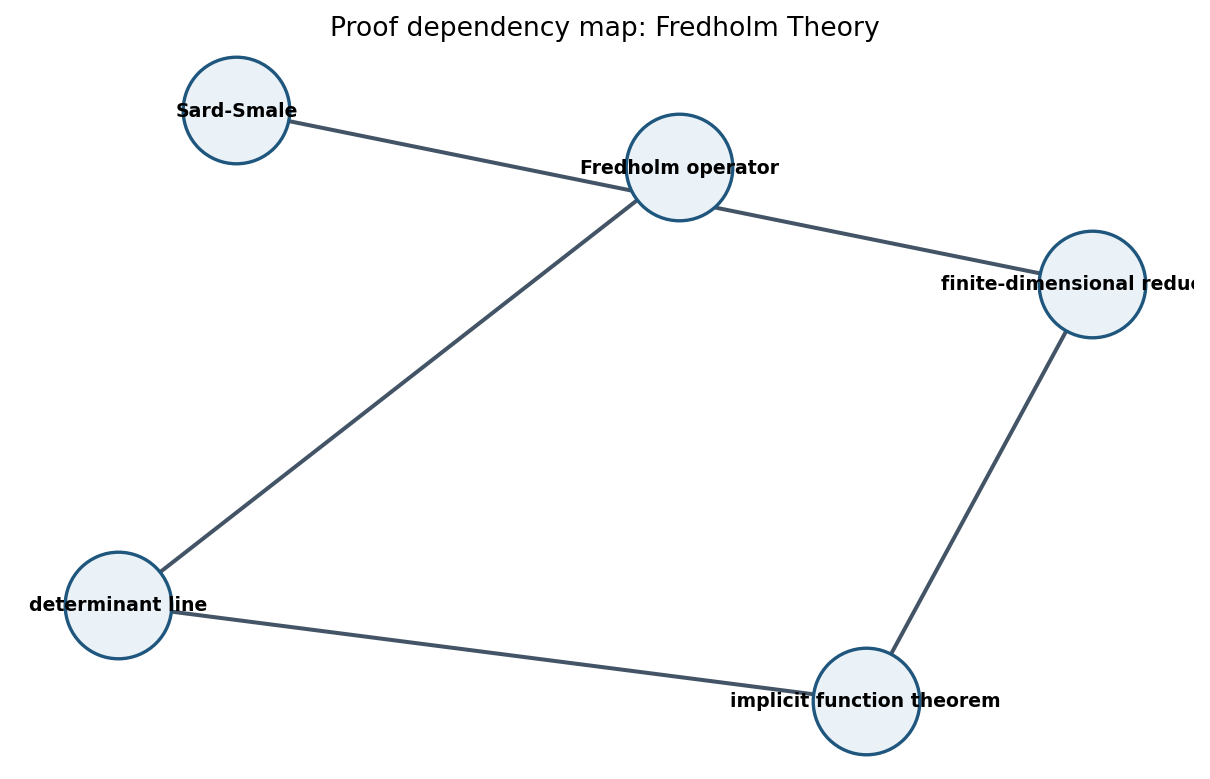

{'nodes': 5,
 'edges': 4,
 'is_directed_acyclic_graph': True,
 'source_span': '531-548',
 'passed': True}

In [2]:
CONCEPT_NODES = ['Fredholm operator', 'determinant line', 'implicit function theorem', 'finite-dimensional reduction', 'Sard-Smale']
CONCEPT_EDGES = [('Fredholm operator', 'determinant line'), ('determinant line', 'implicit function theorem'), ('implicit function theorem', 'finite-dimensional reduction'), ('finite-dimensional reduction', 'Sard-Smale')]

G = nx.DiGraph()
G.add_nodes_from(CONCEPT_NODES)
G.add_edges_from(CONCEPT_EDGES)
pos = nx.spring_layout(G, seed=25, k=1.35)

fig, ax = plt.subplots(figsize=(9.5, 5.8))
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=18, width=1.8, edge_color="#435466")
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=2300, node_color="#eaf2f8", edgecolors="#1f567d", linewidths=1.5)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8.5, font_weight="bold")
ax.set_title('Proof dependency map: Fredholm Theory')
ax.set_axis_off()
graph_path = save_matplotlib(fig, UNIT, "figures", "proof-dependency-map.png")
plt.close(fig)

graph_check = {
    "nodes": len(CONCEPT_NODES),
    "edges": len(CONCEPT_EDGES),
    "is_directed_acyclic_graph": nx.is_directed_acyclic_graph(G),
    "source_span": '531-548',
    "passed": len(CONCEPT_NODES) >= 5 and nx.is_directed_acyclic_graph(G),
}
graph_json = save_json(graph_check, UNIT, "checks", "proof-dependency-map.json")
display_artifact(graph_path, width=780)
graph_check


## Executable Model

This section builds a small model for one core mechanism in Fredholm Theory. The model is intentionally finite and inspectable: it creates an artifact, records a JSON check, and gives a learner a parameter to perturb in the applied lab.


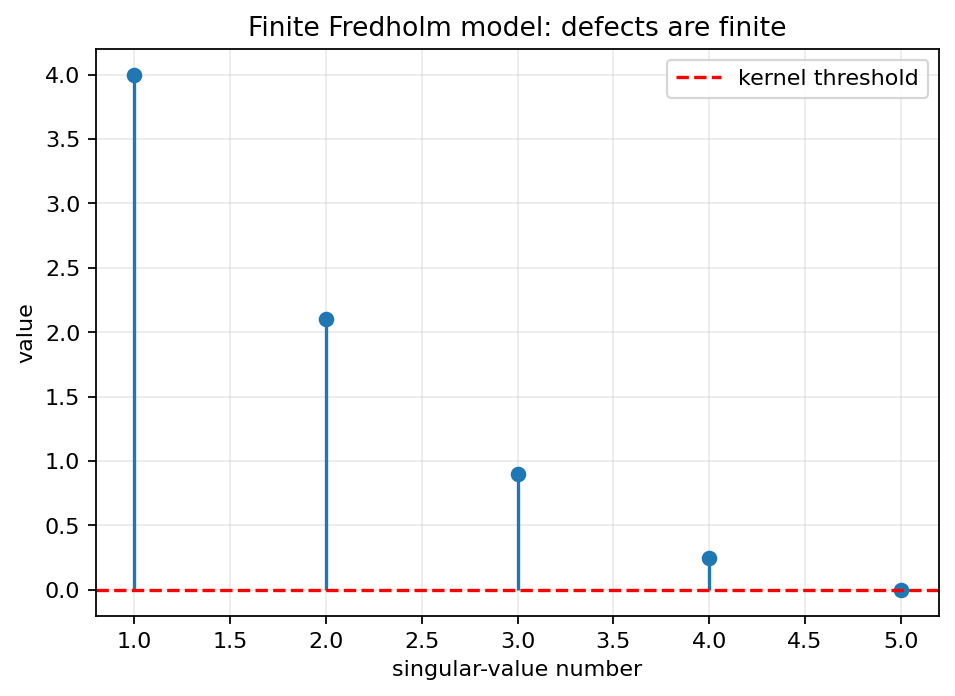

{'domain_dimension': 6,
 'target_dimension': 5,
 'rank': 4,
 'kernel_dimension': 2,
 'cokernel_dimension': 1,
 'index': 1,
 'rank_nullity_ok': True,
 'passed': True}

In [3]:
rng = np.random.default_rng(7)
singular_values = np.array([4.0, 2.1, 0.9, 0.25, 0.0])
m, ncols, rank = 5, 6, 4
kernel_dim = ncols - rank
cokernel_dim = m - rank
index = kernel_dim - cokernel_dim
threshold = 1e-8

fig, ax = plt.subplots(figsize=(6.8, 4.6))
ax.stem(np.arange(1, len(singular_values) + 1), singular_values, basefmt=" ")
ax.axhline(threshold, color="red", linestyle="--", label="kernel threshold")
ax.set_xlabel("singular-value number")
ax.set_ylabel("value")
ax.set_title("Finite Fredholm model: defects are finite")
ax.legend()
ax.grid(True, alpha=0.25)
fig_path = save_matplotlib(fig, UNIT, "figures", "fredholm-singular-value-index.png")
plt.close(fig)

check = {
    "domain_dimension": ncols,
    "target_dimension": m,
    "rank": rank,
    "kernel_dimension": kernel_dim,
    "cokernel_dimension": cokernel_dim,
    "index": index,
    "rank_nullity_ok": bool(rank + kernel_dim == ncols),
    "passed": bool(index == ncols - m and rank + kernel_dim == ncols),
}
check_path = save_json(check, UNIT, "checks", "fredholm-index-checks.json")
display_artifact(fig_path, width=660)
check


## Invariant Ledger

The ledger records the chapter vocabulary as computational objects plus explicit checks. It is a small source map inside the notebook: every row names what should be inspected when the figure or experiment is changed.


In [4]:
ledger_rows = [{'item': 'Fredholm operator', 'computational_object': 'matrix with stable finite defect', 'check': 'dim ker - dim coker'}, {'item': 'determinant line', 'computational_object': 'top exterior powers of kernel and cokernel', 'check': 'orientation sign'}, {'item': 'implicit function theorem', 'computational_object': 'surjective derivative', 'check': 'local zero-set dimension'}, {'item': 'finite-dimensional reduction', 'computational_object': 'project to cokernel obstruction', 'check': 'obstruction rank'}, {'item': 'Sard-Smale', 'computational_object': 'generic regular values', 'check': 'residual set check'}]
table_path = TABLE_DIR / "invariant-ledger.csv"
with table_path.open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=["item", "computational_object", "check"])
    writer.writeheader()
    writer.writerows(ledger_rows)

ledger_check = {
    "row_count": len(ledger_rows),
    "items": [row["item"] for row in ledger_rows],
    "has_source_specific_checks": all(row["check"] for row in ledger_rows),
    "passed": len(ledger_rows) >= 5 and all(row["check"] for row in ledger_rows),
}
ledger_json = save_json(ledger_check, UNIT, "checks", "invariant-ledger.json")
display_artifact(table_path)
ledger_check


{'row_count': 5,
 'items': ['Fredholm operator',
  'determinant line',
  'implicit function theorem',
  'finite-dimensional reduction',
  'Sard-Smale'],
 'has_source_specific_checks': True,
 'passed': True}

## Applied Lab

Move the singular-value threshold. The displayed kernel and cokernel dimensions should change only if the threshold crosses a marked small singular value.

The intended workflow is to change one parameter, rerun the executable model, and then inspect both the figure and JSON check. If the visual impression and the invariant check disagree, trust the check first and then ask what the visualization is hiding.


## Takeaways

    - Fredholm index is the dimension budget for regular moduli spaces.
- Cokernel zero is the linear version of transversality.
- Orientations of determinant lines are what make signed counts meaningful.

    ## Sanity Checks

    The final cell asserts that the generated figures, ledgers, and JSON checks exist, are nonempty, and report successful chapter-specific invariants.


In [5]:
expected = [
    FIG_DIR / "proof-dependency-map.png",
    FIG_DIR / 'fredholm-singular-value-index.png',
    CHECK_DIR / "proof-dependency-map.json",
    CHECK_DIR / 'fredholm-index-checks.json',
    CHECK_DIR / "invariant-ledger.json",
    TABLE_DIR / "invariant-ledger.csv",
]
for path in expected:
    min_bytes = 80 if path.suffix == ".csv" else 512
    assert_artifact(path, min_bytes=min_bytes)

for path in [CHECK_DIR / "proof-dependency-map.json", CHECK_DIR / 'fredholm-index-checks.json', CHECK_DIR / "invariant-ledger.json"]:
    data = json.loads(path.read_text(encoding="utf-8"))
    assert data.get("passed") is True, path

print(f"Validated {len(expected)} artifacts for {UNIT}")


Validated 6 artifacts for appendix-a
